# Comparação de modelos de triagem hospitalar

Este notebook compara dois modelos para prever a classe de urgência a partir do texto clínico preparado no notebook anterior:

- baseline: **TF-IDF + Regressão Logística**;
- rede neural: **classificador textual PyTorch do `ml_prep_kit`**.

A comparação usa somente o conjunto de validação. O conjunto de teste permanece reservado para a avaliação final do modelo escolhido.

In [1]:
import sys
import time
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings(
    "ignore",
    message="IProgress not found.*",
)

TRAINING_DB = PROJECT_ROOT / "data/processed/training_data.db"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

from ml_prep_kit import (
    ExperimentTracker,
    ModelEvaluator,
    SklearnTorchTextClassifier,
    SQLiteDataFrameStore,
)

plt.style.use("ggplot")
TARGET_ORDER = ["normal", "atencao", "urgente"]

## 1. Dados de treino e validação

Os splits já foram definidos de forma estratificada e agrupada por hash do texto. Assim, textos repetidos não aparecem em conjuntos diferentes.

In [3]:
store = SQLiteDataFrameStore(TRAINING_DB)
data = store.load_dataframe(
    table_name="training_data",
    columns=[
        "clinical_text",
        "target",
        "split",
        "dataset_version",
    ],
)

dataset_versions = data["dataset_version"].unique()
if len(dataset_versions) != 1:
    raise ValueError("A base deve possuir uma única versão.")
dataset_version = dataset_versions[0]

split_summary = (
    data.groupby(["split", "target"])
    .size()
    .unstack(fill_value=0)
    .reindex(["train", "validation", "test"])
    .reindex(columns=TARGET_ORDER)
)
display(split_summary)

train_data = data.loc[data["split"] == "train"]
validation_data = data.loc[data["split"] == "validation"]

X_train = train_data["clinical_text"]
y_train = train_data["target"]
X_validation = validation_data["clinical_text"]
y_validation = validation_data["target"]

print(f"Treino: {len(train_data):,} registros")
print(f"Validação: {len(validation_data):,} registros")

target,normal,atencao,urgente
split,,,
train,2232,3802,1316
validation,477,814,282
test,477,813,282


Treino: 7,350 registros
Validação: 1,573 registros


## 2. Modelos e critério de escolha

O modelo vencedor será aquele com maior **F1 macro** na validação. Essa métrica atribui a mesma importância às três classes, mesmo com quantidades diferentes de registros. A latência média por registro será usada como critério secundário.

In [4]:
baseline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=10_000,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

pytorch_classifier = SklearnTorchTextClassifier(
    embedding_dim=64,
    learning_rate=0.005,
    epochs=10,
    batch_size=128,
    max_vocab_size=10_000,
    max_sequence_length=128,
    random_seed=42,
)

model_definitions = {
    "TF-IDF + Logistic Regression": {
        "model": baseline,
        "parameters": {
            "vectorizer": "TF-IDF",
            "ngram_range": "(1, 2)",
            "max_features": 10_000,
            "class_weight": "balanced",
            "random_state": 42,
            "dataset_version": dataset_version,
        },
    },
    "PyTorch Text Classifier": {
        "model": pytorch_classifier,
        "parameters": {
            "embedding_dim": 64,
            "learning_rate": 0.005,
            "epochs": 10,
            "batch_size": 128,
            "max_vocab_size": 10_000,
            "max_sequence_length": 128,
            "random_seed": 42,
            "dataset_version": dataset_version,
        },
    },
}

In [5]:
evaluator = ModelEvaluator()
experiments = {}

for model_name, definition in model_definitions.items():
    model = definition["model"]

    training_start = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - training_start

    inference_start = time.perf_counter()
    predictions = model.predict(X_validation)
    inference_seconds = time.perf_counter() - inference_start

    metrics = evaluator.evaluate_classification(
        y_validation,
        predictions,
    )
    metrics.update(
        {
            "training_seconds": training_seconds,
            "inference_seconds": inference_seconds,
            "latency_ms_per_record": (
                inference_seconds * 1_000 / len(X_validation)
            ),
        }
    )
    experiments[model_name] = {
        **definition,
        "predictions": predictions,
        "metrics": metrics,
    }
    print(f"{model_name}: treinamento concluído.")

TF-IDF + Logistic Regression: treinamento concluído.


PyTorch Text Classifier: treinamento concluído.


## 3. Métricas e latência

In [6]:
results = pd.DataFrame(
    [
        {
            "model": model_name,
            "accuracy": result["metrics"]["accuracy"],
            "precision_macro": result["metrics"][
                "precision_macro"
            ],
            "recall_macro": result["metrics"]["recall_macro"],
            "f1_macro": result["metrics"]["f1_macro"],
            "training_seconds": result["metrics"][
                "training_seconds"
            ],
            "latency_ms_per_record": result["metrics"][
                "latency_ms_per_record"
            ],
        }
        for model_name, result in experiments.items()
    ]
).sort_values(
    ["f1_macro", "latency_ms_per_record"],
    ascending=[False, True],
)

display(
    results.style.format(
        {
            "accuracy": "{:.3f}",
            "precision_macro": "{:.3f}",
            "recall_macro": "{:.3f}",
            "f1_macro": "{:.3f}",
            "training_seconds": "{:.3f}",
            "latency_ms_per_record": "{:.4f}",
        }
    )
)

,model,accuracy,precision_macro,recall_macro,f1_macro,training_seconds,latency_ms_per_record
0,TF-IDF + Logistic Regression,0.571,0.551,0.583,0.558,0.377,0.0174
1,PyTorch Text Classifier,0.610,0.591,0.523,0.535,1.307,0.0119


In [7]:
class_reports = []
for model_name, result in experiments.items():
    report = evaluator.evaluate_classification_by_class(
        y_validation,
        result["predictions"],
    )
    report.insert(0, "model", model_name)
    class_reports.append(report)

display(
    pd.concat(class_reports, ignore_index=True).style.format(
        {
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
        }
    )
)

,model,class,precision,recall,f1,support
0,TF-IDF + Logistic Regression,atencao,0.678,0.522,0.590,814
1,TF-IDF + Logistic Regression,normal,0.562,0.650,0.603,477
2,TF-IDF + Logistic Regression,urgente,0.414,0.578,0.482,282
3,PyTorch Text Classifier,atencao,0.618,0.770,0.686,814
4,PyTorch Text Classifier,normal,0.608,0.549,0.577,477
5,PyTorch Text Classifier,urgente,0.547,0.248,0.341,282


## 4. Matrizes de confusão

As matrizes estão normalizadas pela classe real. Cada linha mostra a proporção de registros classificados em cada categoria.

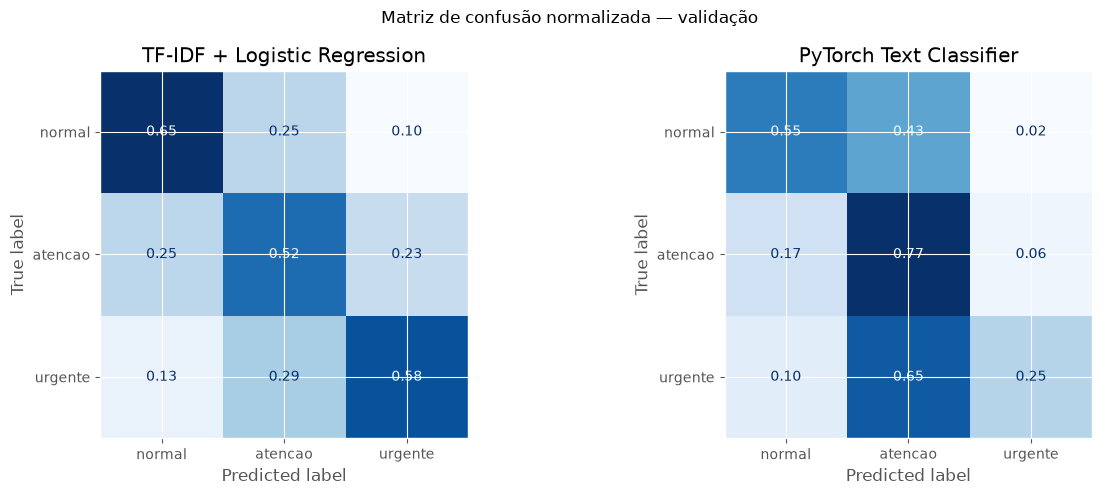

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5))

for axis, (model_name, result) in zip(
    axes,
    experiments.items(),
    strict=True,
):
    ConfusionMatrixDisplay.from_predictions(
        y_validation,
        result["predictions"],
        labels=TARGET_ORDER,
        normalize="true",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(model_name)

figure.suptitle("Matriz de confusão normalizada — validação")
figure.tight_layout()
plt.show()

## 5. Registro no MLflow

Cada execução registra parâmetros, métricas e o modelo treinado em um banco MLflow local.

In [9]:
tracker = ExperimentTracker(
    experiment_name="hospital-triage-model-comparison",
    tracking_uri=f"sqlite:///{MLFLOW_DB}",
)

baseline_result = experiments["TF-IDF + Logistic Regression"]
baseline_run_id = tracker.log_training_run(
    run_name="tfidf-logistic-regression",
    model=baseline_result["model"],
    parameters=baseline_result["parameters"],
    metrics=baseline_result["metrics"],
)

pytorch_result = experiments["PyTorch Text Classifier"]
input_example = pytorch_result["model"].transform_texts(
    X_validation.iloc[:5]
)
pytorch_run_id = tracker.log_pytorch_training_run(
    run_name="pytorch-text-classifier",
    model=pytorch_result["model"].model_module_,
    parameters=pytorch_result["parameters"],
    metrics=pytorch_result["metrics"],
    input_example=input_example,
)

run_ids = {
    "TF-IDF + Logistic Regression": baseline_run_id,
    "PyTorch Text Classifier": pytorch_run_id,
}
display(
    pd.DataFrame(
        {"model": run_ids.keys(), "mlflow_run_id": run_ids.values()}
    )
)

,model,mlflow_run_id
0,TF-IDF + Logistic Regression,6febb7084fe347e7978923b11afdc3e4
1,PyTorch Text Classifier,5169360d58bb4689b788409b84fd3e5b


## 6. Escolha do modelo

In [10]:
winner = results.iloc[0]
runner_up = results.iloc[1]
f1_difference = winner["f1_macro"] - runner_up["f1_macro"]

decision = (
    f"### Modelo selecionado: {winner['model']}\n\n"
    "O modelo foi escolhido pelo maior **F1 macro na validação** "
    f"({winner['f1_macro']:.3f}), uma diferença de "
    f"{f1_difference:.3f} em relação ao outro modelo. Esse critério "
    "equilibra o desempenho entre `normal`, `atencao` e `urgente`, "
    "em vez de favorecer somente a classe mais frequente. A latência "
    "observada também é compatível com uma aplicação interativa.\n\n"
    "O próximo passo é avaliar uma única vez esse modelo no conjunto "
    "de teste e, depois, otimizar seus hiperparâmetros sem usar o teste "
    "para tomada de decisão."
)
display(Markdown(decision))

### Modelo selecionado: TF-IDF + Logistic Regression

O modelo foi escolhido pelo maior **F1 macro na validação** (0.558), uma diferença de 0.023 em relação ao outro modelo. Esse critério equilibra o desempenho entre `normal`, `atencao` e `urgente`, em vez de favorecer somente a classe mais frequente. A latência observada também é compatível com uma aplicação interativa.

O próximo passo é avaliar uma única vez esse modelo no conjunto de teste e, depois, otimizar seus hiperparâmetros sem usar o teste para tomada de decisão.